# **About Data**
    1. id (Unique id for each patient)
    2. age (Age of the patient in years)
    3. origin (place of study)
    4. sex (Male/Female)
    5. cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
    6. trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
    7. chol (serum cholesterol in mg/dl)
    8. fbs (if fasting blood sugar > 120 mg/dl)
    9. restecg (resting electrocardiographic results)Values: [normal, stt abnormality, lv hypertrophy]
    10. thalach: maximum heart rate achieved
    11. exang: exercise-induced angina (True/ False)
    12. oldpeak: ST depression induced by exercise relative to rest
    13. lope: the slope of the peak exercise ST segment
    14. ca: number of major vessels (0-3) colored by fluoroscopy
    15. thal: [normal; fixed defect; reversible defect]
    16. num: the predicted attribute


# **Context¶**
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

# **Load Libraries:**

In [14]:
pip install matplotlib --upgrade

  Using cached matplotlib-3.9.1-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.2.1-cp312-cp312-win_amd64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.53.1-cp312-cp312-win_amd64.whl.metadata (165 kB)
  Using cached kiwisolver-1.4.5-cp312-cp312-win_amd64.whl.metadata (6.5 kB)
  Using cached pillow-10.4.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.1.2-py3-none-any.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.0 MB 1.7 MB/s eta 0:00:05
    --------------------------------------- 0.2/8.0 MB 1.9 MB/s eta 0:00:05
   - -------------------------------------- 0.3/8.0 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.0 MB 2.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.0 MB 2.3 MB/s eta 0:00:04
   --- ------------------------------------ 0.

In [16]:
pip install seaborn --upgrade

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install matplotlib seaborn

  Using cached matplotlib-3.9.1-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.2.1-cp312-cp312-win_amd64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.53.1-cp312-cp312-win_amd64.whl.metadata (165 kB)
  Using cached kiwisolver-1.4.5-cp312-cp312-win_amd64.whl.metadata (6.5 kB)
  Using cached pillow-10.4.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.1.2-py3-none-any.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------

ERROR: THESE PACKAGES DO NOT MATCH THE HASHES FROM THE REQUIREMENTS FILE. If you have updated the package versions, please update the hashes. Otherwise, examine the package contents carefully; someone may have tampered with them.
    unknown package:
        Expected sha256 44a21d922f78ce40435cb35b43dd7d573cf2a30138d5c4b709d19f00e3907fd7
             Got        61c76477046bbb5dcd71970847b29ea030fb20d150ac7bab5565735ff1ff74e9



In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC  # Corrected from SVM to SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split

In [18]:
df_uci = pd.read_csv("heart_disease_uci (1).csv")
df_uci.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [24]:
df_uci.shape

(920, 16)

In [25]:
df_uci.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [26]:
df_uci.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

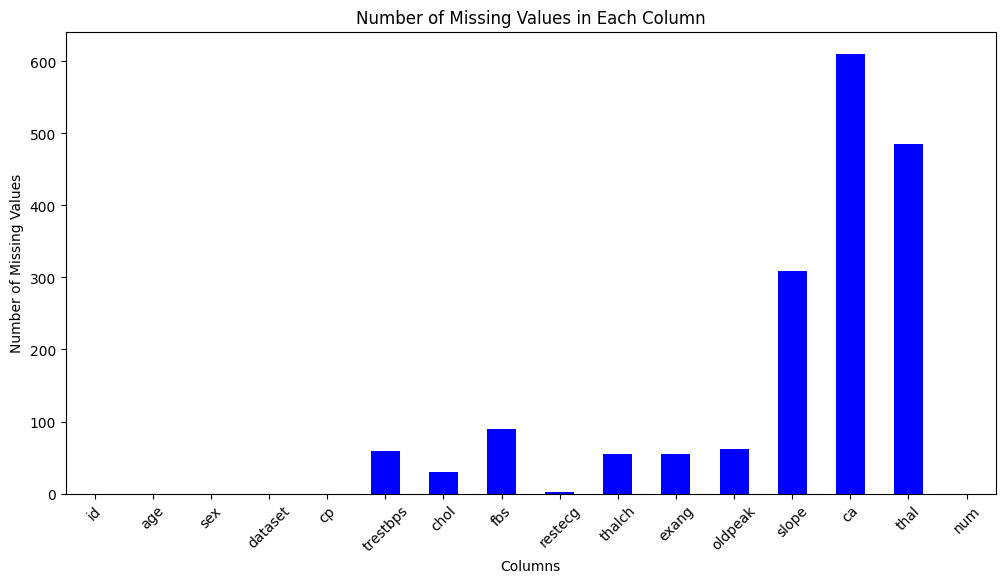

In [27]:
missing_values = df_uci.isnull().sum()


plt.figure(figsize=(12, 6))
missing_values.plot(kind='bar', color='blue')
plt.title('Number of Missing Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

# **Missing Values Count by Feature:**

    1. trestbps (Resting Blood Pressure): **59** missing values.
    2. chol (Serum Cholesterol): **30** missing values.
    3. fbs (Fasting Blood Sugar): **90** missing values.
    4. restecg (Resting Electrocardiographic Results): **2** missing values.
    5. thalch (Maximum Heart Rate Achieved): **55** missing values.
    6. exang (Exercise Induced Angina): **55** missing values.
    7. oldpeak (ST Depression Induced by Exercise Relative to Rest): **62** missing values.
    8. slope (Slope of the Peak Exercise ST Segment): **309** missing values.
    9. ca (Number of Major Vessels Colored by Fluoroscopy): **611** missing values.
    10. thal (Thalassemia): **486** missing values.

    Impact of Missing Values: Missing values can affect the analysis and modeling process
    by introducing bias and reducing the effectiveness of predictive models. It's important to handle them appropriately
    to avoid misleading results.

In [7]:
categorical_cols = df_uci.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [8]:
numerical_cols = df_uci.select_dtypes(include=['number']).columns
numerical_cols

Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')

In [9]:
df_uci[numerical_cols] = df_uci[numerical_cols].fillna(df_uci[numerical_cols].mean())


for col in categorical_cols:
    df_uci[col] = df_uci[col].fillna(df_uci[col].mode()[0])


print(df_uci.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


/tmp/ipykernel_18/1377684015.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_uci[col] = df_uci[col].fillna(df_uci[col].mode()[0])


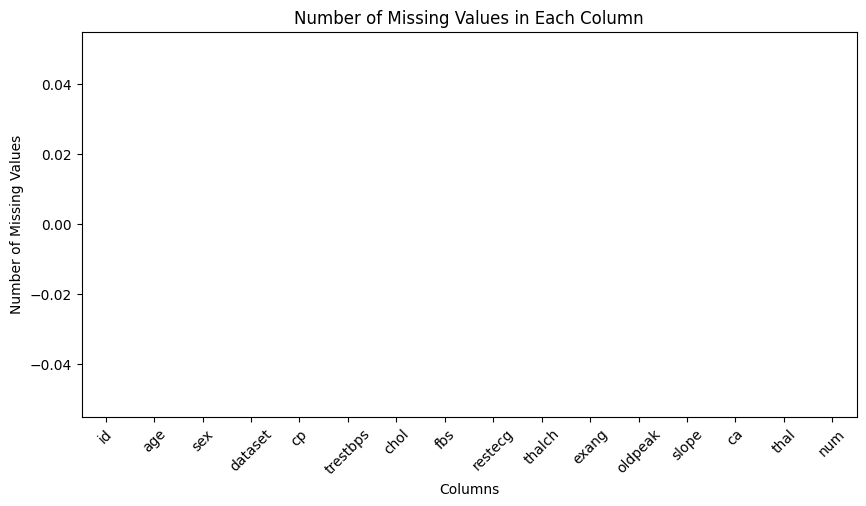

In [10]:
plt.figure(figsize=(10, 5))
df_uci.isnull().sum().plot(kind='bar', color='skyblue')
plt.title('Number of Missing Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

# **Data Visualization:**

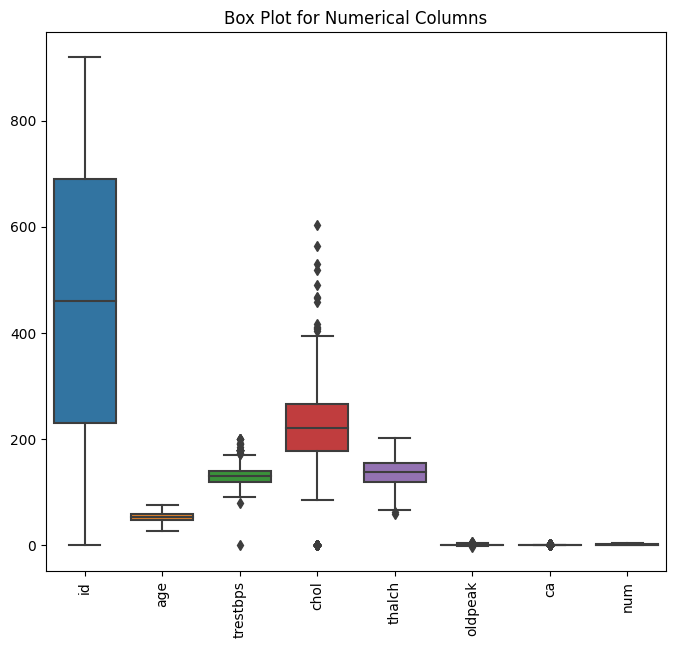

In [11]:
# Create a box plot for numerical columns
plt.figure(figsize=(8, 7))
sns.boxplot(data=df_uci[numerical_cols])
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Box Plot for Numerical Columns')
plt.show()

# **we'll remove outlier**

In [12]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

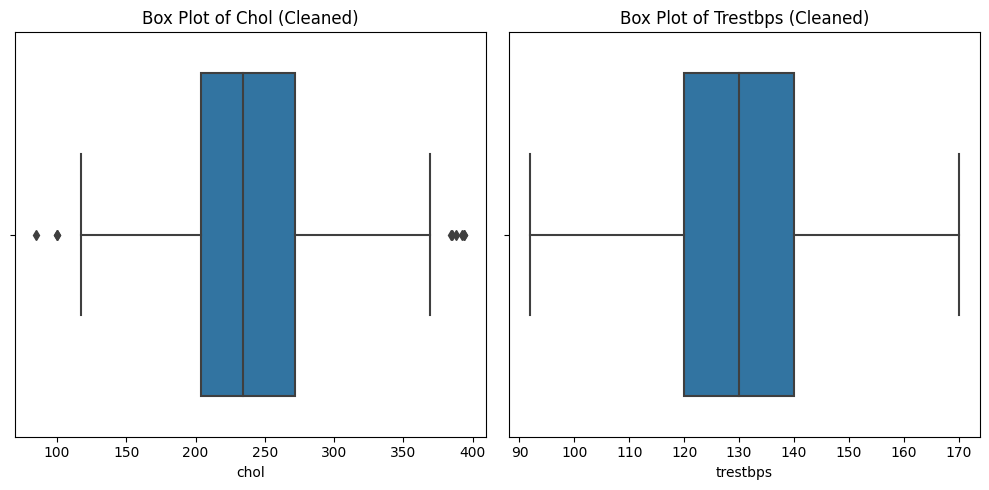

In [13]:
df_uci_cleaned = remove_outliers(df_uci, 'chol')
df_uci_cleaned = remove_outliers(df_uci_cleaned, 'trestbps')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_uci_cleaned, x='chol')
plt.title('Box Plot of Chol (Cleaned)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_uci_cleaned, x='trestbps')
plt.title('Box Plot of Trestbps (Cleaned)')

plt.tight_layout()
plt.show()

# **Histogram plot**

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

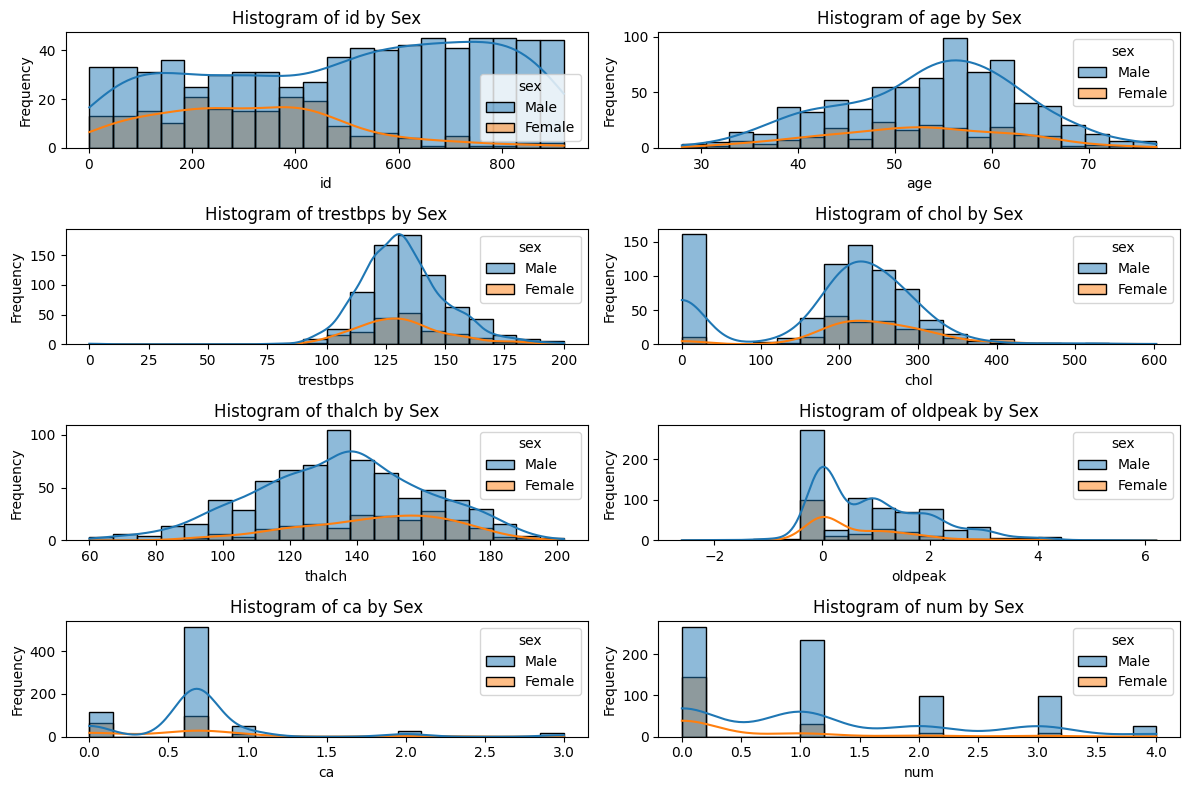

In [14]:
num_numeric_cols = df_uci.select_dtypes(include=['number']).shape[1]
num_cols_per_row = 2
num_rows = (num_numeric_cols + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(12, 8))

for i, col in enumerate(df_uci.select_dtypes(include=['number'])):
    plt.subplot(num_rows, num_cols_per_row, i+1)
    sns.histplot(data=df_uci, x=col, hue='sex', kde=True, bins=20)
    plt.title(f'Histogram of {col} by Sex')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

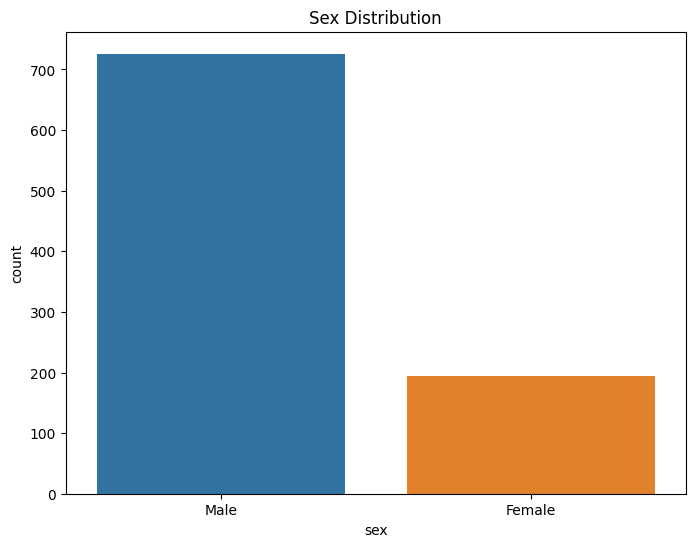

In [15]:
plt.figure(figsize=(8,6))
sns.countplot(x='sex',data=df_uci)
plt.title('Sex Distribution')
plt.show()

In [16]:
df_uci['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

# **Explanation:**
**Importing Plotly Express:**

**1. import plotly.express as px:**

This imports Plotly Express, which is a high-level interface for creating a variety of plots in Plotly with a simple syntax.

**2. Creating a Sunburst Plot:**

    1. px.sunburst(): This function creates a sunburst plot. A sunburst plot is a hierarchical visualization that shows hierarchical data organized as a set of nested rings. Each ring corresponds to a level in the hierarchy, with the innermost ring representing the root level and subsequent rings representing the nested levels.
    2. df_uci: This is the DataFrame used as the data source for the plot.
    3. path=['sex','dataset']: This parameter specifies the sequence of columns in the DataFrame that will be used to define the hierarchy of the sunburst plot. In this case, the hierarchy is defined by the sex column and then the dataset column.
    4. values='age': This parameter specifies the column in the DataFrame that will be used to determine the size of each segment in the sunburst plot. In this case, it's the age column.
    5. color='num': This parameter specifies the column in the DataFrame that will be used to determine the color of each segment in the sunburst plot. In this case, it's the num column.

In [17]:
import plotly.express as px


fig = px.sunburst(df_uci,
                  path=['sex','dataset'],
                  values='age' , color='num')

fig.show()

# **bar plot with dataset:**

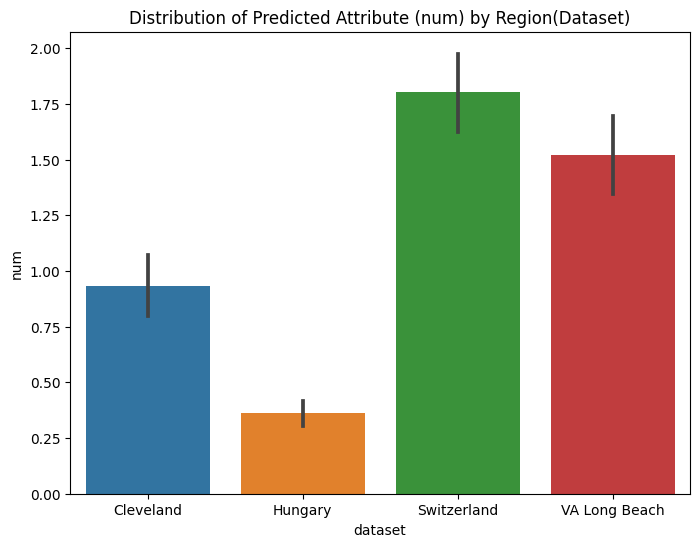

In [18]:
plt.figure(figsize=(8,6))
sns.barplot(x='dataset',y='num',data=df_uci)
plt.title('Distribution of Predicted Attribute (num) by Region(Dataset)')
plt.show()

# **Scatter Plot**

In [19]:
import plotly.express as px


fig1 = px.scatter(df_uci, x='age', y='chol', color='sex', size='trestbps', hover_data=['cp', 'dataset'])


fig1.update_layout(title='Scatter Plot: Age vs Cholesterol (colored by sex, sized by trestbps)')

fig1.show()


/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



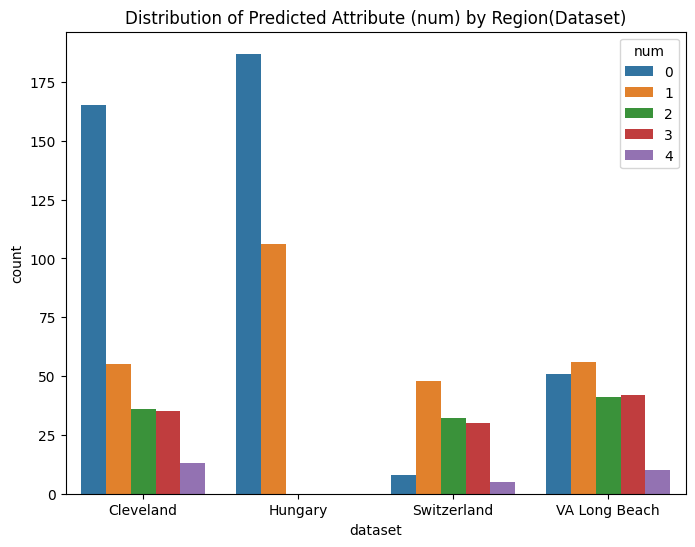

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(x='dataset',hue='num',data=df_uci)
plt.title('Distribution of Predicted Attribute (num) by Region(Dataset)')
plt.show()

# **Distribution of thalassemia types varies across different regions**

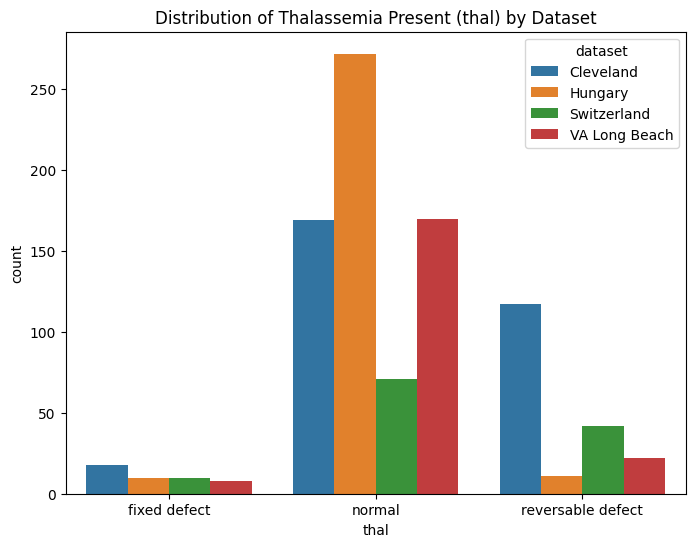

In [21]:
plt.figure(figsize=(8, 6))
sns.countplot(x='thal', hue='dataset', data=df_uci)
plt.title('Distribution of Thalassemia Present (thal) by Dataset')
plt.show()

In [22]:
grouped_counts = df_uci.groupby(['thal', 'dataset']).size()

print("Grouped counts by 'thal' and 'dataset':")
print(grouped_counts)

Grouped counts by 'thal' and 'dataset':
thal               dataset      
fixed defect       Cleveland         18
                   Hungary           10
                   Switzerland       10
                   VA Long Beach      8
normal             Cleveland        169
                   Hungary          272
                   Switzerland       71
                   VA Long Beach    170
reversable defect  Cleveland        117
                   Hungary           11
                   Switzerland       42
                   VA Long Beach     22
dtype: int64


# **Distribution of age Present (age) by sex**

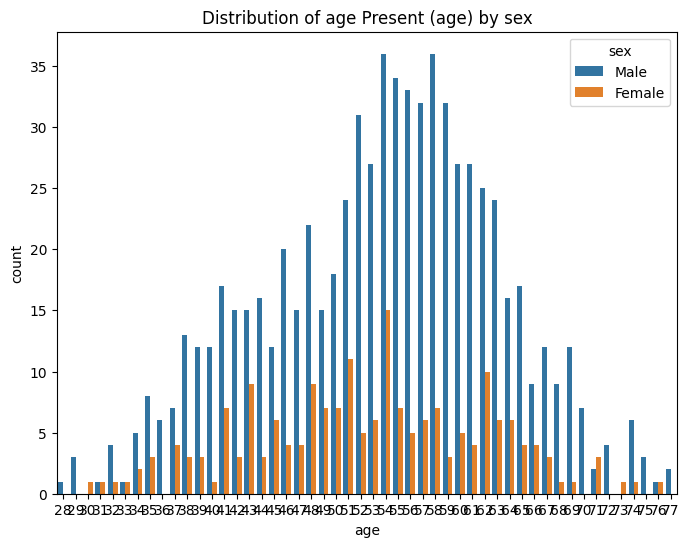

In [23]:
plt.figure(figsize=(8, 6))
sns.countplot(x='age', hue='sex', data=df_uci)
plt.title('Distribution of age Present (age) by sex')
plt.show()

# **Distribution of chest pain type Present (cp) by num**

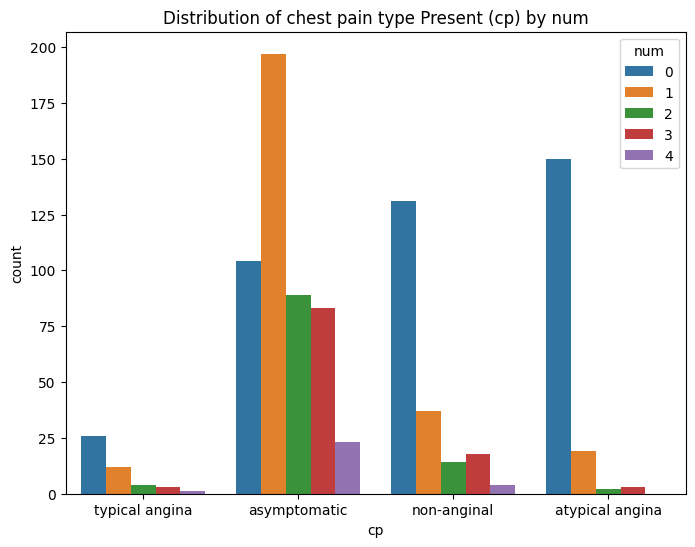

In [24]:
plt.figure(figsize=(8, 6))
sns.countplot(x='cp', hue='num', data=df_uci)
plt.title('Distribution of chest pain type Present (cp) by num')
plt.show()

# **grouped by**

In [25]:
grouped_counts = df_uci.groupby(['cp', 'num']).size()

print("Grouped counts by 'cp' and 'num':")
print(grouped_counts)

Grouped counts by 'cp' and 'num':
cp               num
asymptomatic     0      104
                 1      197
                 2       89
                 3       83
                 4       23
atypical angina  0      150
                 1       19
                 2        2
                 3        3
non-anginal      0      131
                 1       37
                 2       14
                 3       18
                 4        4
typical angina   0       26
                 1       12
                 2        4
                 3        3
                 4        1
dtype: int64


# **Distribution of resting blood pressure Present (trestbps) by age**

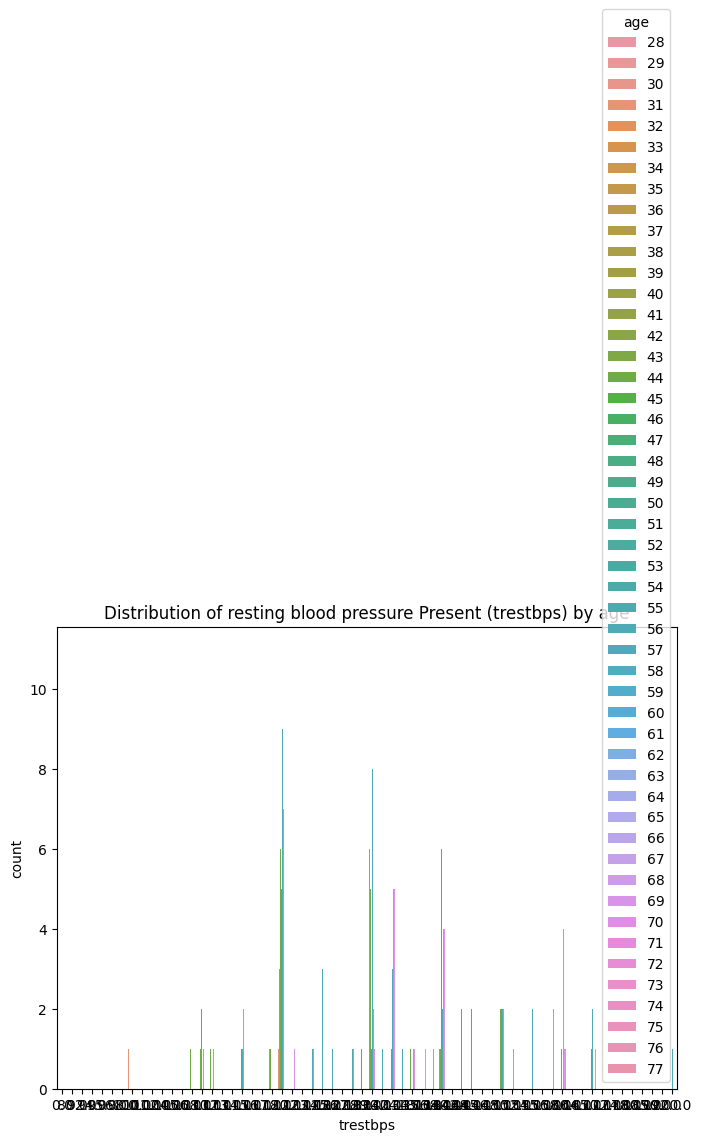

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(x='trestbps', hue='age', data=df_uci)
plt.title('Distribution of resting blood pressure Present (trestbps) by age')
plt.show()

# **grouped by**

In [27]:
grouped_counts = df_uci.groupby(['trestbps', 'age']).size()

print("Grouped counts by 'trestbps' and 'age':")
print(grouped_counts)

Grouped counts by 'trestbps' and 'age':
trestbps  age
0.0       55     1
80.0      53     1
92.0      38     1
94.0      39     1
          51     1
                ..
192.0     54     1
200.0     54     1
          56     1
          61     1
          64     1
Length: 514, dtype: int64


# **Target variable**

In [28]:
X = df_uci[['num', 'age', 'chol', 'trestbps']]
y = df_uci['num']

# **spliting the data in x and y**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Feature Scaling**

In [30]:
from sklearn.preprocessing import StandardScaler

evaluation_metrics = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **● Logistic Regression**

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


LR_model = LogisticRegression(penalty='l1', solver='liblinear')
LR_model.fit(X_train_scaled, y_train)
LR_predictions = LR_model.predict(X_test_scaled)
LR_proba = LR_model.predict_proba(X_test_scaled)

gini_coefficients = {}

for class_label in range(LR_proba.shape[1]):
    class_proba = LR_proba[:, class_label]
    gini_coefficients[f'Class {class_label}'] = roc_auc_score((y_test == class_label).astype(int), class_proba) * 2 - 1

average_gini_coefficient = np.mean(list(gini_coefficients.values()))

conf_matrix = confusion_matrix(y_test, LR_predictions)
accuracy = accuracy_score(y_test, LR_predictions)
precision = precision_score(y_test, LR_predictions, average='weighted')
recall = recall_score(y_test, LR_predictions, average='weighted')
f1 = f1_score(y_test, LR_predictions, average='weighted')

LR_metrics = {
    'Confusion Matrix': conf_matrix,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Gini Coefficients': gini_coefficients,
    'Average Gini Coefficient': average_gini_coefficient
}

evaluation_metrics['Logistic Regression'] = LR_metrics

print("Evaluation Metrics for Logistic Regression:")
for metric_name, metric_value in LR_metrics.items():
    print(f"{metric_name}: {metric_value}")


Evaluation Metrics for Logistic Regression:
Confusion Matrix: [[75  0  0  0  0]
 [ 0 54  0  0  0]
 [ 0 25  0  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  4  0]]
Accuracy: 0.842391304347826
Precision: 0.7306778572738947
Recall: 0.842391304347826
F1 Score: 0.7771330500163451
Gini Coefficients: {'Class 0': 1.0, 'Class 1': 0.9923076923076923, 'Class 2': 0.7116981132075471, 'Class 3': 1.0, 'Class 4': 1.0}
Average Gini Coefficient: 0.9408011611030478


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# **● Decision Tree Classifier**

In [32]:
dtc_model = DecisionTreeClassifier(max_depth=5, min_samples_split=30, min_samples_leaf=20)
dtc_model.fit(X_train_scaled, y_train)
dtc_predictions = dtc_model.predict(X_test_scaled)
dtc_proba = dtc_model.predict_proba(X_test_scaled)

gini_coefficients = {}

for class_label in range(dtc_proba.shape[1]):
    class_proba = dtc_proba[:, class_label]
    gini_coefficients[f'Class {class_label}'] = roc_auc_score((y_test == class_label).astype(int), class_proba) * 2 - 1

average_gini_coefficient = np.mean(list(gini_coefficients.values()))

conf_matrix = confusion_matrix(y_test, dtc_predictions)
accuracy = accuracy_score(y_test, dtc_predictions)
precision = precision_score(y_test, dtc_predictions, average='weighted')
recall = recall_score(y_test, dtc_predictions, average='weighted')
f1 = f1_score(y_test, dtc_predictions, average='weighted')

dtc_metrics = {
    'Confusion Matrix': conf_matrix,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Gini Coefficients': gini_coefficients,
    'Average Gini Coefficient': average_gini_coefficient
}

evaluation_metrics['DecisionTreeClassifier'] = dtc_metrics

print("Evaluation Metrics for Decision Tree Classifier:")
for metric_name, metric_value in dtc_metrics.items():
    print(f"{metric_name}: {metric_value}")

Evaluation Metrics for Decision Tree Classifier:
Confusion Matrix: [[75  0  0  0  0]
 [ 0 54  0  0  0]
 [ 0  0 25  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  0  4]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Gini Coefficients: {'Class 0': 1.0, 'Class 1': 1.0, 'Class 2': 1.0, 'Class 3': 1.0, 'Class 4': 1.0}
Average Gini Coefficient: 1.0


# **● Random Forest Classifier**

In [33]:
rfc_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10, min_samples_leaf=5)
rfc_model.fit(X_train_scaled, y_train)
rfc_predictions = rfc_model.predict(X_test_scaled)
rfc_proba = rfc_model.predict_proba(X_test_scaled)

gini_coefficients = {}

for class_label in range(rfc_proba.shape[1]):
    class_proba = rfc_proba[:, class_label]
    gini_coefficients[f'Class {class_label}'] = roc_auc_score((y_test == class_label).astype(int), class_proba) * 2 - 1

average_gini_coefficient = np.mean(list(gini_coefficients.values()))

conf_matrix = confusion_matrix(y_test, rfc_predictions)
accuracy = accuracy_score(y_test, rfc_predictions)
precision = precision_score(y_test, rfc_predictions, average='weighted')
recall = recall_score(y_test, rfc_predictions, average='weighted')
f1 = f1_score(y_test, rfc_predictions, average='weighted')

rfc_metrics = {
    'Confusion Matrix': conf_matrix,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Gini Coefficients': gini_coefficients,
    'Average Gini Coefficient': average_gini_coefficient
}

evaluation_metrics['RandomForestClassifier'] = rfc_metrics

print("Evaluation Metrics for Random Forest Classifier:")
for metric_name, metric_value in rfc_metrics.items():
    print(f"{metric_name}: {metric_value}")

Evaluation Metrics for Random Forest Classifier:
Confusion Matrix: [[75  0  0  0  0]
 [ 0 54  0  0  0]
 [ 0  0 25  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  4  0]]
Accuracy: 0.9782608695652174
Precision: 0.9594202898550724
Recall: 0.9782608695652174
F1 Score: 0.968167701863354
Gini Coefficients: {'Class 0': 1.0, 'Class 1': 0.9999999999999998, 'Class 2': 1.0, 'Class 3': 0.9990262901655307, 'Class 4': 1.0}
Average Gini Coefficient: 0.999805258033106


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# **● Gradient Boosting Classifier**

In [34]:
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2, min_samples_leaf=1, subsample=1.0)
gbc_model.fit(X_train_scaled, y_train)
gbc_predictions = gbc_model.predict(X_test_scaled)
gbc_proba = gbc_model.predict_proba(X_test_scaled)

gini_coefficients = {}

for class_label in range(gbc_proba.shape[1]):
    class_proba = gbc_proba[:, class_label]
    gini_coefficients[f'Class {class_label}'] = roc_auc_score((y_test == class_label).astype(int), class_proba) * 2 - 1

average_gini_coefficient = np.mean(list(gini_coefficients.values()))

conf_matrix = confusion_matrix(y_test, rfc_predictions)
accuracy = accuracy_score(y_test, rfc_predictions)
precision = precision_score(y_test, gbc_predictions, average='weighted')
recall = recall_score(y_test, gbc_predictions, average='weighted')
f1 = f1_score(y_test, gbc_predictions, average='weighted')

gbc_metrics = {
    'Confusion Matrix': conf_matrix,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Gini Coefficients': gini_coefficients,
    'Average Gini Coefficient': average_gini_coefficient
}

evaluation_metrics['GradientBoostingClassifier'] = gbc_metrics

print("Evaluation Metrics for Gradient Boosting Classifier:")
for metric_name, metric_value in gbc_metrics.items():
    print(f"{metric_name}: {metric_value}")

Evaluation Metrics for Gradient Boosting Classifier:
Confusion Matrix: [[75  0  0  0  0]
 [ 0 54  0  0  0]
 [ 0  0 25  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  4  0]]
Accuracy: 0.9782608695652174
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Gini Coefficients: {'Class 0': 1.0, 'Class 1': 0.9999999999999998, 'Class 2': 1.0, 'Class 3': 1.0, 'Class 4': 1.0}
Average Gini Coefficient: 1.0


# **Support Vector Machine (SVM)**


In [35]:
from sklearn.svm import SVC

svc_model = SVC(C=1.0, kernel='rbf', gamma='scale')

svc_model.fit(X_train_scaled, y_train)

svc_predictions = svc_model.predict(X_test_scaled)

gini_coefficients = {}

if hasattr(svc_model, "predict_proba"):
    svc_proba = svc_model.predict_proba(X_test_scaled)
    for class_label in range(svc_proba.shape[1]):
        class_proba = svc_proba[:, class_label]
        gini_coefficients[f'Class {class_label}'] = roc_auc_score((y_test == class_label).astype(int), class_proba) * 2 - 1

    average_gini_coefficient = np.mean(list(gini_coefficients.values()))
else:
    average_gini_coefficient = None

conf_matrix = confusion_matrix(y_test, svc_predictions)
accuracy = accuracy_score(y_test, svc_predictions)
precision = precision_score(y_test, svc_predictions, average='weighted')
recall = recall_score(y_test, svc_predictions, average='weighted')
f1 = f1_score(y_test, svc_predictions, average='weighted')

svc_metrics = {
    'Confusion Matrix': conf_matrix,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Average Gini Coefficient': average_gini_coefficient
}

evaluation_metrics['SVM'] = svc_metrics

print("Evaluation Metrics for SVM:")
for metric_name, metric_value in svc_metrics.items():
    print(f"{metric_name}: {metric_value}")

Evaluation Metrics for SVM:
Confusion Matrix: [[75  0  0  0  0]
 [ 0 54  0  0  0]
 [ 0  0 25  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  0  4]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Average Gini Coefficient: None


# **Report Findings:**


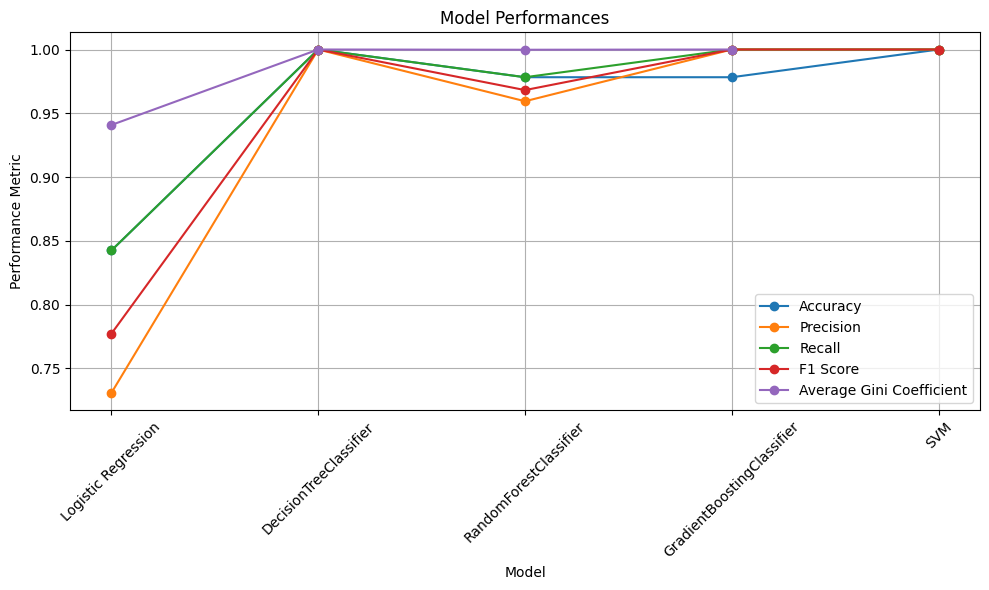

In [36]:
import matplotlib.pyplot as plt

model_performance = {}

for model_name, metrics in evaluation_metrics.items():
    model_performance[model_name] = {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1 Score': metrics['F1 Score'],
        'Average Gini Coefficient': metrics.get('Average Gini Coefficient', None)
    }

models = list(model_performance.keys())
metrics = list(model_performance[models[0]].keys())

fig, ax = plt.subplots(figsize=(10, 6))

for metric_name in metrics:
    values = [model_performance[model_name][metric_name] for model_name in models]
    ax.plot(models, values, marker='o', label=metric_name)

ax.set_xlabel('Model')
ax.set_ylabel('Performance Metric')
ax.set_title('Model Performances')
ax.legend()

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()


This code will create a line plot where each line represents a different evaluation metric (e.g., Accuracy, Precision, Recall, F1 Score, Average Gini Coefficient), and each point on the line corresponds to a specific model. You can analyze the plot to determine which model performed best based on the evaluation metrics.